# Gaussian Mixture Model (GMM) for Data Distribution Estimation and Visualization

## Overview

This project implements a **Gaussian Mixture Model (GMM)** to estimate and visualize the underlying probability distribution of a dataset. GMM is a powerful probabilistic model that assumes the observed data are generated from a mixture of several Gaussian (normal) distributions, each representing a latent cluster or subpopulation within the data.

Unlike traditional clustering methods that assign each data point to a single cluster, GMM provides a **soft probabilistic assignment**, allowing each observation to belong to multiple components with different probabilities.

---

## Motivation

Real-world datasets often exhibit complex, multimodal distributions that cannot be accurately represented by a single Gaussian distribution. Gaussian Mixture Models provide a flexible framework for:

- Modeling multimodal data distributions
- Discovering hidden structures in data
- Performing probabilistic clustering
- Estimating probability density functions
- Visualizing underlying data-generating processes

This implementation aims to demonstrate how GMM can be used to estimate and visualize the distribution of data in an intuitive and interpretable manner.

---
## Mathematical Formulation

A Gaussian Mixture Model (GMM) assumes that the probability density function of the data is a weighted sum of multiple Gaussian distributions:

$$
p(x)=\sum_{k=1}^{K}\pi_k \mathcal{N}(x|\mu_k,\Sigma_k)
$$

where:

- $K$ : Number of Gaussian components
- $\pi_k$ : Mixing coefficient (weight) of component $k$
- $\mu_k$ : Mean vector of component $k$
- $\Sigma_k$ : Covariance matrix of component $k$
- $\mathcal{N}(x|\mu_k,\Sigma_k)$ : Gaussian probability density function

The mixing coefficients satisfy:

$$
\sum_{k=1}^{K}\pi_k = 1,
\qquad
\pi_k \geq 0
$$

---

## Expectation-Maximization (EM) Algorithm

### E-Step

Compute the posterior probability (responsibility) that observation $x_i$ belongs to component $k$:

$$
\gamma(z_{ik})=
\frac{\pi_k \mathcal{N}(x_i|\mu_k,\Sigma_k)}
{\sum_{j=1}^{K}\pi_j \mathcal{N}(x_i|\mu_j,\Sigma_j)}
$$

---

### M-Step

First, compute the effective number of samples assigned to component $k$:

$$
N_k=\sum_{i=1}^{N}\gamma(z_{ik})
$$

Update the mixing coefficients:

$$
\pi_k=\frac{N_k}{N}
$$

Update the means:

$$
\mu_k=
\frac{1}{N_k}
\sum_{i=1}^{N}
\gamma(z_{ik})x_i
$$

Update the covariance matrices:

$$
\Sigma_k=
\frac{1}{N_k}
\sum_{i=1}^{N}
\gamma(z_{ik})
(x_i-\mu_k)(x_i-\mu_k)^T
$$
---

## Features

- Gaussian Mixture Model implementation for density estimation
- Automatic estimation of multimodal distributions
- Visualization of Gaussian components
- Visualization of the estimated probability density function
- Soft probabilistic clustering
- Easy-to-understand graphical representation of data distributions

---

## Applications

Gaussian Mixture Models are widely used in:

- Data distribution estimation
- Density estimation
- Pattern recognition
- Anomaly detection
- Signal processing
- Image segmentation
- Financial modeling
- Behavioral data analysis
- Neuroscience and cognitive science research
- Economic decision-making studies

---

## Example Workflow

```text
Input Data
      │
      ▼
Fit Gaussian Mixture Model
      │
      ▼
Estimate Gaussian Components
      │
      ▼
Compute Probability Density Function
      │
      ▼
Visualize Distribution and Components
```

---

## Why Use GMM?

Compared with simple histogram-based methods or single Gaussian models, GMM offers:

| Feature | Histogram | Single Gaussian | GMM |
|---------|------------|----------------|-----|
| Smooth Density Estimation | ❌ | ✅ | ✅ |
| Multimodal Distribution Modeling | ❌ | ❌ | ✅ |
| Probabilistic Interpretation | ❌ | ✅ | ✅ |
| Soft Clustering | ❌ | ❌ | ✅ |
| Flexible Representation | ❌ | ❌ | ✅ |

---

## Conclusion

The Gaussian Mixture Model is a flexible and mathematically principled approach for estimating complex data distributions. By representing data as a weighted combination of multiple Gaussian components, GMM provides powerful tools for density estimation, probabilistic clustering, and data visualization, making it highly suitable for exploratory data analysis and modeling complex real-world datasets.

---

**Keywords:** Gaussian Mixture Model (GMM), Density Estimation, Probability Distribution, Expectation-Maximization (EM), Probabilistic Clustering, Data Visualization, Machine Learning.

# Clustering

In [244]:
from sklearn.datasets import make_blobs

In [245]:
X, y = make_blobs(n_samples=400, centers=4, random_state=0, cluster_std=.7)

In [246]:
X

array([[ 0.4997845 ,  6.26373486],
       [-2.89316688,  2.45595805],
       [-3.12893804,  3.09392135],
       [ 0.65739733,  4.31602274],
       [-2.70375676,  2.29560231],
       [-1.77876538,  7.80040115],
       [ 2.25121474,  0.82895839],
       [-0.15345841,  4.15486913],
       [-1.83433668,  3.04481916],
       [ 1.71950845,  1.33191447],
       [-0.89961909,  7.81712545],
       [ 2.59654461,  0.06894721],
       [ 2.56509832,  3.28573136],
       [-2.5394783 ,  3.47809083],
       [-0.66949462,  2.96328154],
       [ 3.42440614,  1.17072899],
       [-1.85510894,  1.37687336],
       [ 1.55154445,  0.32856857],
       [ 1.25790923,  3.82442026],
       [-1.17782082,  3.65146277],
       [-0.98691985,  3.63848944],
       [-2.16303829,  2.62085993],
       [-2.07259605,  7.0373226 ],
       [ 1.09294153,  4.74830933],
       [ 0.78866772,  4.8655068 ],
       [-2.25971391,  6.98807992],
       [-0.52416885,  7.13811117],
       [ 0.40706768,  3.09538951],
       [ 1.80789093,

In [247]:
X.shape

(400, 2)

In [248]:
y.view()

array([3, 2, 2, 0, 2, 3, 1, 0, 2, 1, 3, 1, 0, 2, 2, 1, 2, 1, 0, 2, 2, 2,
       3, 0, 0, 3, 3, 0, 0, 1, 0, 0, 2, 0, 2, 3, 1, 0, 1, 0, 2, 3, 1, 0,
       1, 3, 1, 1, 1, 3, 3, 3, 2, 3, 3, 2, 0, 1, 1, 2, 1, 1, 1, 1, 0, 2,
       1, 0, 2, 3, 2, 0, 2, 3, 1, 2, 0, 2, 3, 2, 2, 0, 1, 3, 0, 2, 2, 0,
       2, 1, 2, 1, 0, 2, 2, 3, 0, 1, 1, 1, 3, 1, 0, 0, 2, 3, 0, 3, 1, 2,
       2, 2, 0, 2, 3, 1, 3, 2, 3, 3, 1, 2, 1, 3, 0, 3, 1, 1, 1, 0, 3, 3,
       3, 2, 0, 2, 3, 0, 3, 2, 0, 2, 2, 3, 2, 1, 0, 2, 1, 2, 1, 0, 1, 0,
       3, 2, 1, 2, 2, 2, 0, 2, 3, 2, 2, 3, 1, 1, 2, 3, 3, 3, 3, 1, 1, 1,
       0, 2, 0, 3, 0, 3, 2, 0, 3, 2, 3, 0, 0, 3, 0, 0, 3, 2, 3, 3, 3, 1,
       1, 0, 0, 2, 1, 1, 3, 0, 2, 3, 0, 3, 0, 0, 1, 1, 3, 1, 0, 3, 1, 3,
       2, 0, 3, 2, 2, 2, 1, 3, 0, 3, 0, 2, 0, 0, 3, 1, 2, 1, 0, 2, 1, 0,
       0, 3, 1, 0, 3, 0, 1, 2, 2, 1, 2, 0, 3, 3, 0, 0, 1, 3, 0, 2, 2, 2,
       3, 0, 0, 0, 0, 0, 1, 0, 0, 3, 2, 1, 3, 1, 1, 1, 3, 1, 1, 3, 3, 3,
       1, 0, 1, 0, 1, 2, 0, 1, 2, 0, 1, 1, 0, 2, 3,

In [249]:
import pandas as pd

In [250]:
df = pd.DataFrame({
        "f1" : X[:, 0],
        "f2" : X[:, 1],
        "Label" : y
})

In [251]:
df.head()

,f1,f2,Label
0,0.499784,6.263735,3
1,-2.893167,2.455958,2
2,-3.128938,3.093921,2
3,0.657397,4.316023,0
4,-2.703757,2.295602,2


In [252]:
palette = {
    0: "#e9e903",   
    1: "#008cff",   
    2: "#0be603",   
    3: "#ff0004"
}

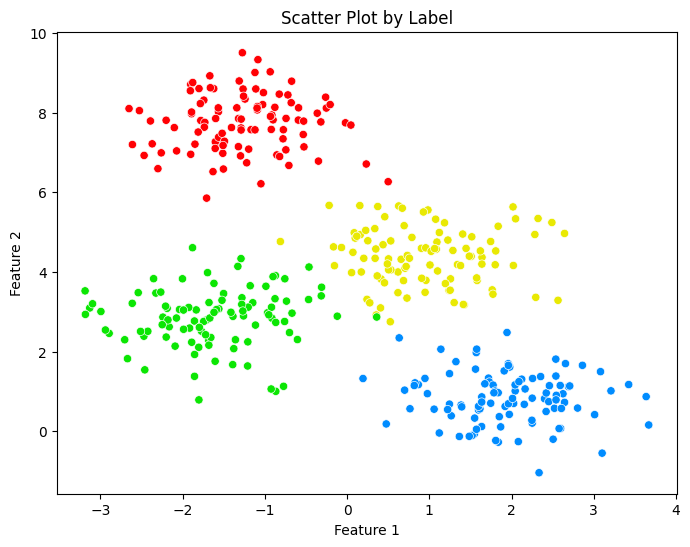

In [253]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="f1",
    y="f2",
    hue="Label",
    palette=palette,
    legend=False
)

plt.title("Scatter Plot by Label")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## K-Means Model

In [254]:
from sklearn.cluster import KMeans

In [255]:
kmeans = KMeans(n_clusters=4, n_init="auto")

In [256]:
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [257]:
df["Cluster"] = kmeans.fit_predict(
    df[["f1", "f2"]]
)

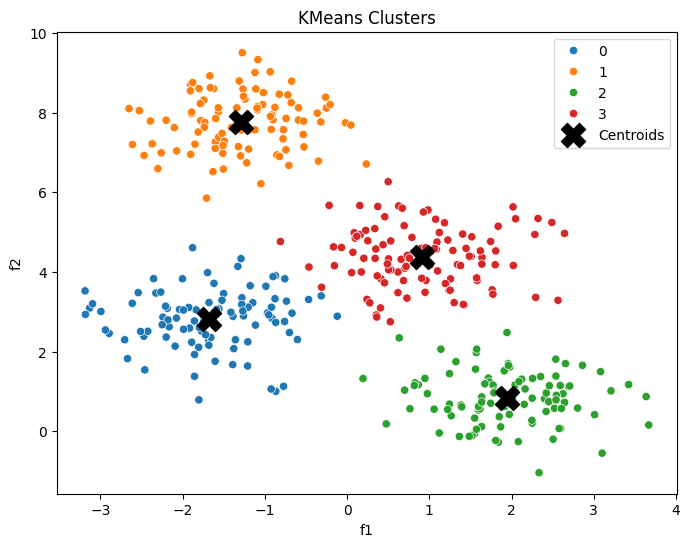

In [258]:
centers = kmeans.cluster_centers_

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="f1",
    y="f2",
    hue="Cluster",
    palette="tab10"
)

plt.title("KMeans Clusters")

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=300,
    c="black",
    label="Centroids"
)

plt.legend()
plt.show()

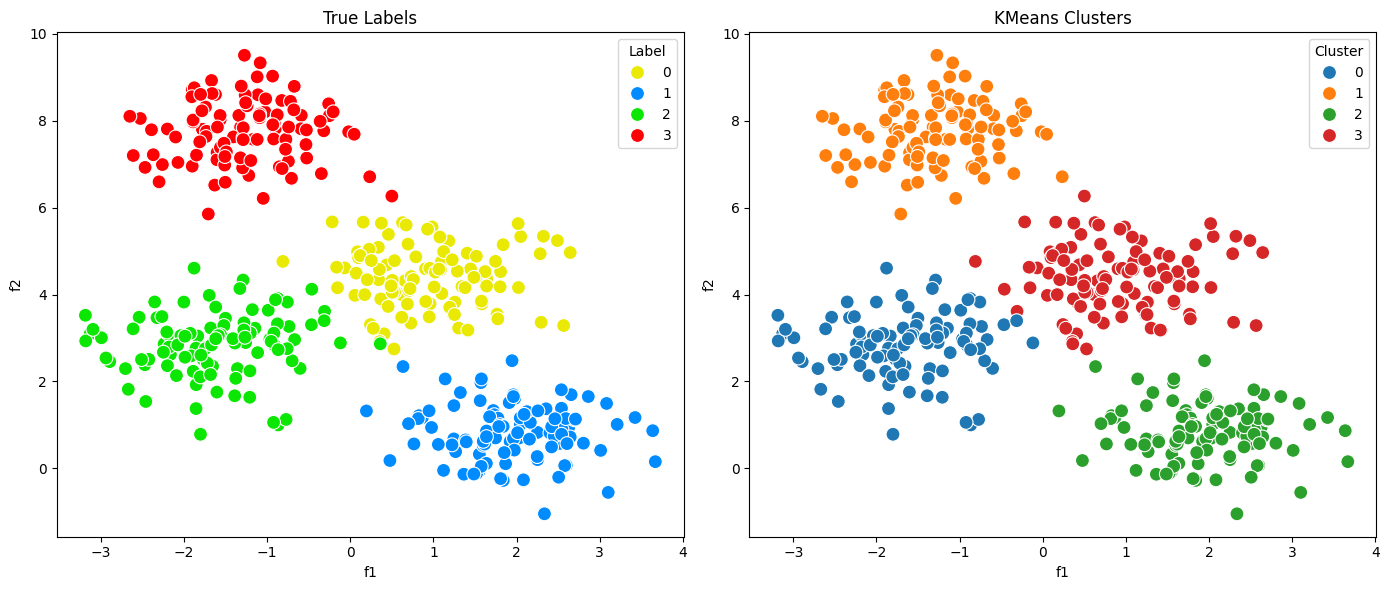

In [259]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=df,
    x="f1",
    y="f2",
    hue="Label",
    palette=palette,
    s=100,
    ax=ax[0]
)

ax[0].set_title("True Labels")

sns.scatterplot(
    data=df,
    x="f1",
    y="f2",
    hue="Cluster",
    palette="tab10",
    s=100,
    ax=ax[1]
)

ax[1].set_title("KMeans Clusters")

plt.tight_layout()
plt.show()

In [260]:
import numpy as np

np.random.seed(42)

A = np.random.randn(2, 2)

In [261]:
X_stretched = X @ A

In [262]:
str_df = pd.DataFrame({
        "f1" : X_stretched[:, 0],
        "f2" : X_stretched[:, 1],
        "Label" : y
})

In [263]:
str_df

,f1,f2,Label
0,4.305199,9.470753,3
1,0.153619,4.140519,2
2,0.449710,5.144755,2
3,3.121977,6.482537,0
4,0.143841,3.870104,2
...,...,...,...
395,3.229176,7.438610,0
396,3.221857,7.246575,0
397,0.883479,0.694888,1
398,2.035405,4.315371,2


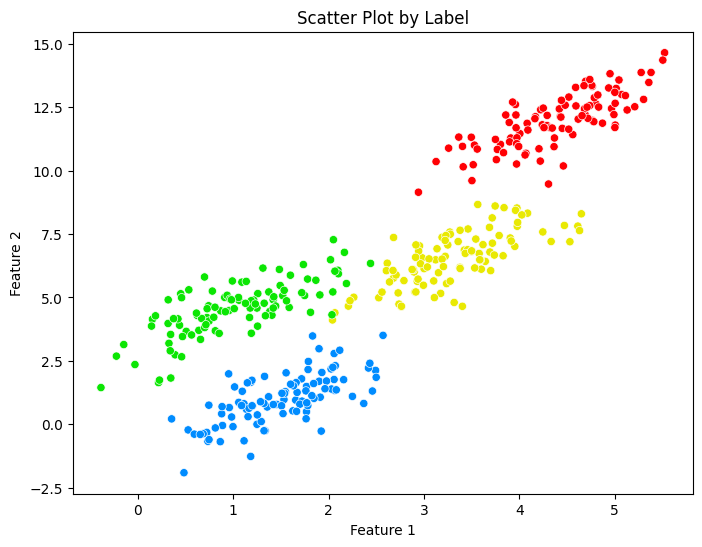

In [264]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=str_df,
    x="f1",
    y="f2",
    hue="Label",
    palette=palette,
    legend=False
)

plt.title("Scatter Plot by Label")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [265]:
kmeans.fit(X_stretched)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [266]:
str_df["Cluster"] = kmeans.fit_predict(
    str_df[["f1", "f2"]]
)

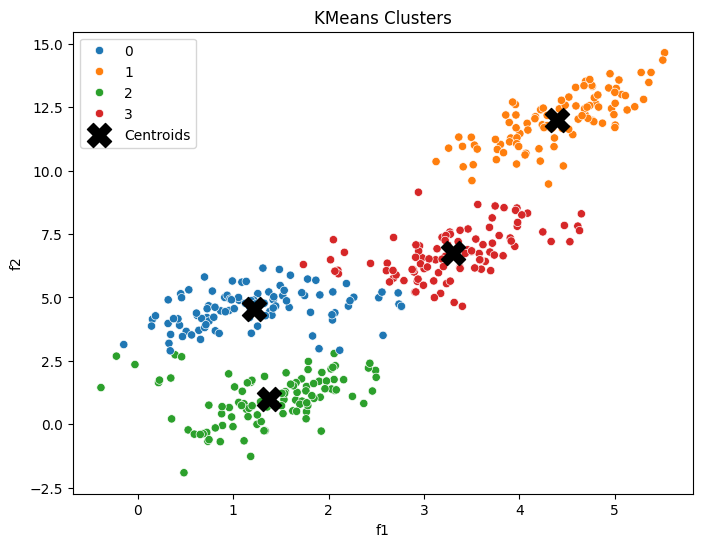

In [267]:
centers = kmeans.cluster_centers_

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=str_df,
    x="f1",
    y="f2",
    hue="Cluster",
    palette="tab10"
)

plt.title("KMeans Clusters")

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=300,
    c="black",
    label="Centroids"
)

plt.legend()
plt.show()

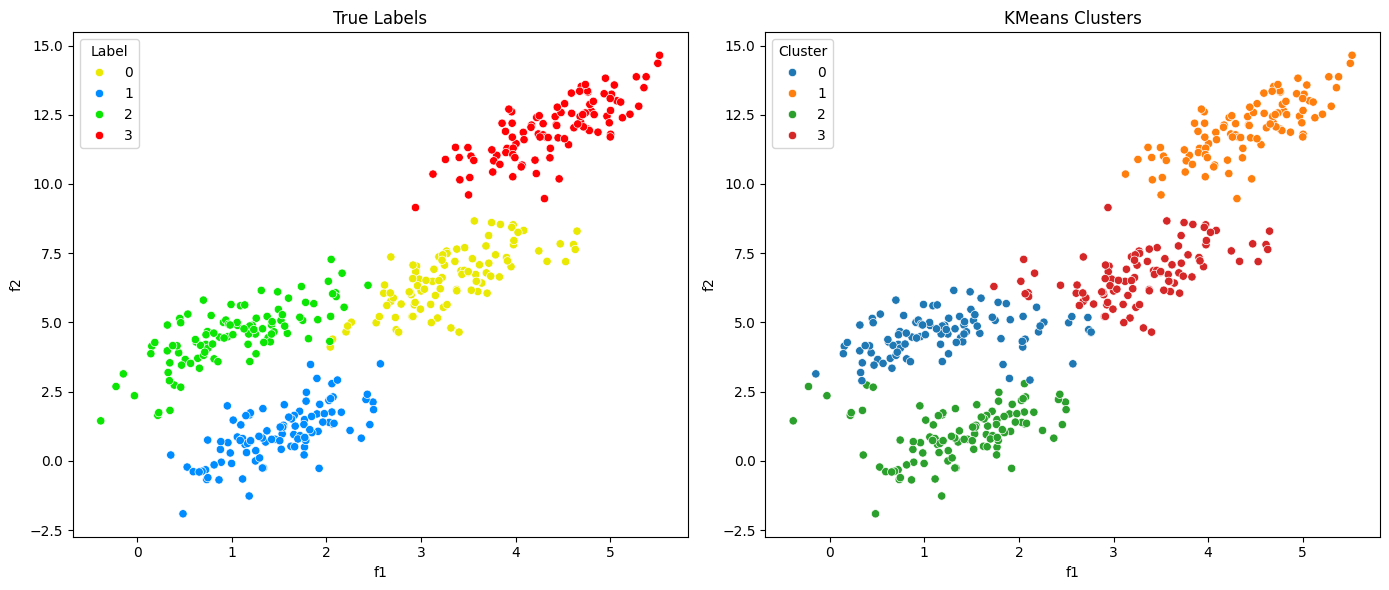

In [268]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=str_df,
    x="f1",
    y="f2",
    hue="Label",
    palette=palette,
    ax=ax[0]
)

ax[0].set_title("True Labels")

sns.scatterplot(
    data=str_df,
    x="f1",
    y="f2",
    hue="Cluster",
    palette="tab10",
    ax=ax[1]
)

ax[1].set_title("KMeans Clusters")

plt.tight_layout()
plt.show()

## Gassian Mixture Model

In [269]:
from sklearn.mixture import GaussianMixture

In [270]:
gmm = GaussianMixture(n_components=4)

In [271]:
gmm.fit(X_stretched)

,"n_components n_components: int, default=1The number of mixture components.",4
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [272]:
str_df["Cluster"] = gmm.fit_predict(
    str_df[["f1", "f2"]]
)

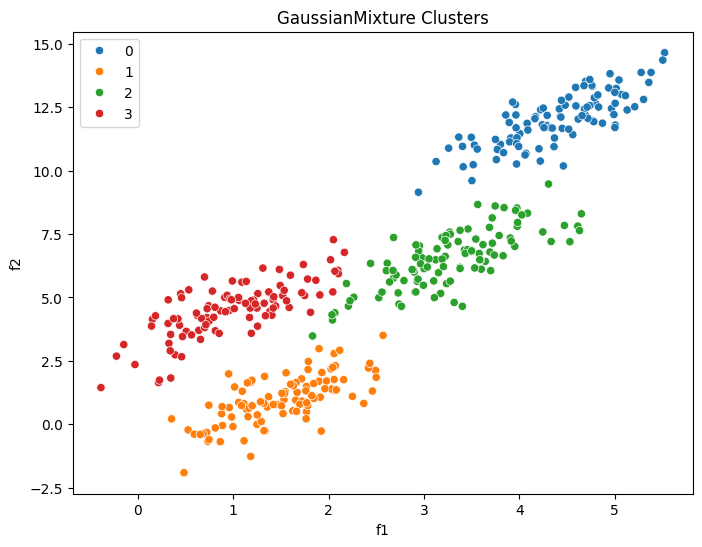

In [273]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=str_df,
    x="f1",
    y="f2",
    hue="Cluster",
    palette="tab10"
)

plt.title("GaussianMixture Clusters")


plt.legend()
plt.show()

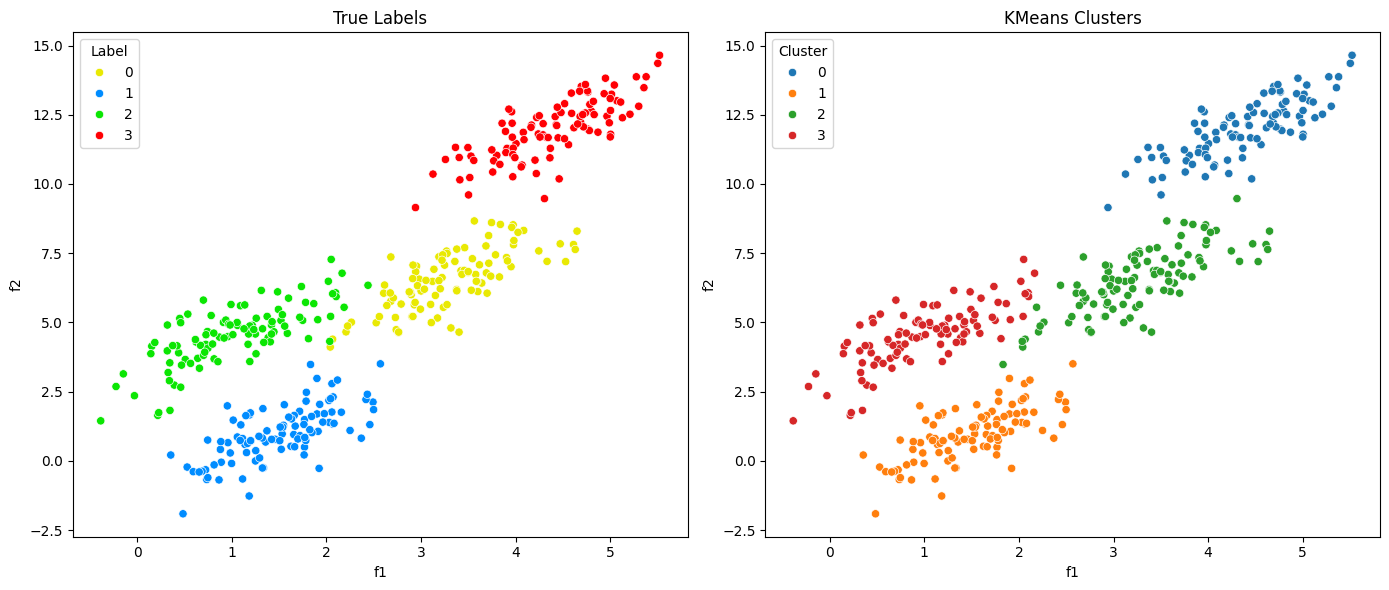

In [274]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=str_df,
    x="f1",
    y="f2",
    hue="Label",
    palette=palette,
    ax=ax[0]
)

ax[0].set_title("True Labels")

sns.scatterplot(
    data=str_df,
    x="f1",
    y="f2",
    hue="Cluster",
    palette="tab10",
    ax=ax[1]
)

ax[1].set_title("KMeans Clusters")

plt.tight_layout()
plt.show()

In [275]:
prob = gmm.predict_proba(X_stretched)
print((prob[:10].round(2)*100))

[[  2.   0.  98.   0.]
 [  0.   0.   0. 100.]
 [  0.   0.   0. 100.]
 [  0.   0. 100.   0.]
 [  0.   0.   0. 100.]
 [100.   0.   0.   0.]
 [  0. 100.   0.   0.]
 [  0.   0.  94.   6.]
 [  0.   0.   0. 100.]
 [  0. 100.   0.   0.]]


c:\Users\Sajjad\anaconda3\envs\ML_Course\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


# Density Estimtion

In [276]:
from sklearn.datasets import make_moons

In [277]:
Xmoon, Ymoon = make_moons(n_samples=500, noise=.1, random_state=42)

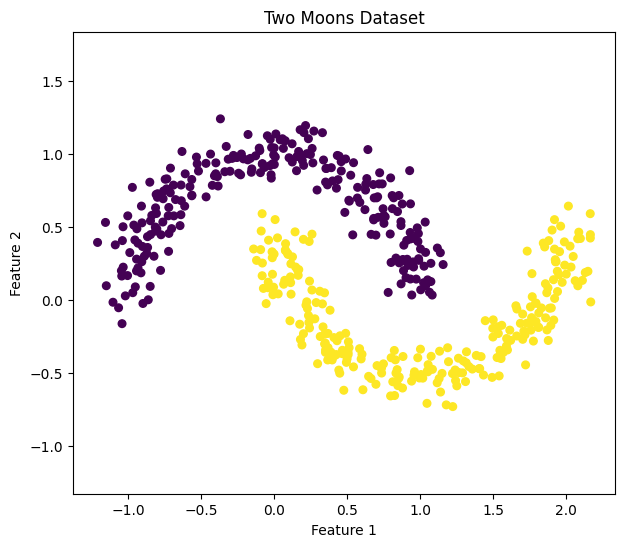

In [278]:
plt.figure(figsize=(7,6))

plt.scatter(
    Xmoon[:,0],
    Xmoon[:,1],
    c=Ymoon,
    # cmap="viridis",
    s=30
)

plt.title("Two Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis("equal")
plt.show()

## Gassian Mixture Model for Density Estimtion

In [279]:
gmm_d = GaussianMixture(n_components=15, random_state=42)

In [280]:
gmm_d.fit(Xmoon)

,"n_components n_components: int, default=1The number of mixture components.",15
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [281]:
labels = gmm_d.predict(Xmoon)

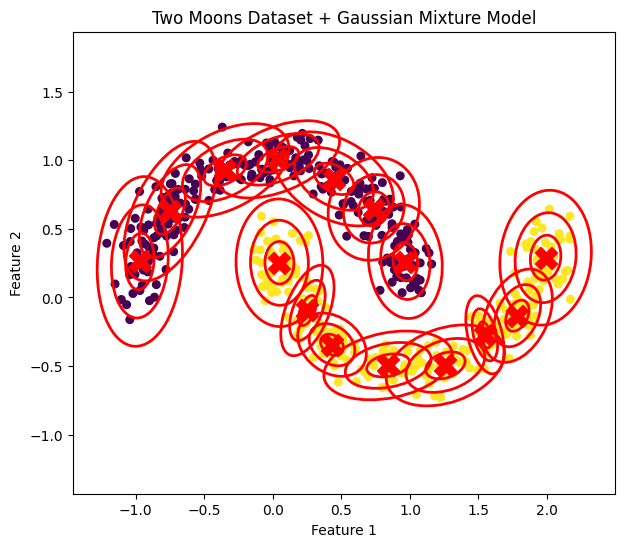

In [282]:
def draw_ellipse(position, covariance, ax=None, **kwargs):

    ax = ax or plt.gca()

    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    # Sort eigenvalues
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(
        np.arctan2(eigenvectors[1,0], eigenvectors[0,0])
    )

    # Draw 1σ, 2σ and 3σ ellipses
    for nsig in range(1,4):

        width = 2 * nsig * np.sqrt(eigenvalues[0])
        height = 2 * nsig * np.sqrt(eigenvalues[1])

        ellipse = Ellipse(
            xy=position,
            width=width,
            height=height,
            angle=angle,
            fill=False,
            lw=2,
            **kwargs
        )

        ax.add_patch(ellipse)


# ==========================
# Plot
# ==========================
plt.figure(figsize=(7,6))

plt.scatter(
    Xmoon[:,0],
    Xmoon[:,1],
    c=Ymoon,
    s=30
)

# Gaussian Means
plt.scatter(
    gmm_d.means_[:,0],
    gmm_d.means_[:,1],
    marker='X',
    s=250,
    c='red'
)

# Gaussian Ellipses
for mean, cov in zip(gmm_d.means_, gmm_d.covariances_):
    draw_ellipse(
        mean,
        cov,
        edgecolor="red"
    )

plt.title("Two Moons Dataset + Gaussian Mixture Model")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis("equal")
plt.show()